# 4장 2강 종합 분석 실습: 퍼널·리텐션·개선 시나리오 통합 적용

실습문제

## 실습 목표

- Ravenstack의 실제 기록으로 시간순 퍼널과 가입 월별 리텐션을 계산한다.
- 전환율·리텐션 표와 그래프를 근거로 초기 가설을 검토한다.
- 교안의 네 가지 기준으로 개선 우선순위를 정한다.
- 이상 신호 → 개선안 → 기대 효과 → A/B 테스트 아이디어를 작성한다.

## 실습 환경 / 데이터

- Python / Colab, pandas, matplotlib. 필요 시 `%pip install pandas matplotlib`를 별도 셀에서 실행합니다.
- 첨부 Ravenstack 중 `accounts`, `subscriptions`, `feature_usage` CSV를 사용합니다. `(2)`가 붙은 파일명과 원래 파일명을 모두 지원합니다.
- `support_tickets`, `churn_events`도 제공된 동일 데이터셋의 일부지만 이번 교안의 퍼널·기능 사용 리텐션 계산에는 필요하지 않아 분석에 사용하지 않습니다.
- CSV를 노트북과 같은 폴더에 두거나 준비 코드의 `DATA_DIR`을 수정하세요.

### 분석 문제와 공통 기준

이번 실습은 **2024년 7~9월 가입한 전체 산업의 신규 계정**을 대상으로 합니다. 기존 파일의 DevTools 구독 상태 비교를, 교안의 가입 시점·시간순 행동 분석에 맞게 변경했습니다. 별도의 1강 답안 없이도 풀 수 있도록 문제와 가설을 아래에 제공합니다.

- 분석 문제: 신규 계정은 가입한 달에 기능 사용까지 얼마나 도달하며, 이후에도 사용하는가?
- 목표 지표: 가입 월 기능 사용 도달률 = 가입 월에 실제 사용한 계정 수 / 대상 가입 계정 수.
- 초기 가설: 가입→구독 시작보다 구독 시작→기능 사용 구간의 전환율이 낮을 것이다. 이후 기능 사용률은 매월 감소할 것이다. **분석 전 가설이며 실제 결과와 다를 수 있습니다.**
- 분석 단위는 `account_id`입니다. 한 계정의 여러 구독·사용 기록은 중복 계정으로 세지 않습니다.
- 실제 사용은 `usage_count > 0`, 사용일이 해당 구독 시작일 이상이며 종료일이 있으면 종료일 이하인 기록입니다. 가입 전 시작된 구독은 이 신규 가입 경로에서 제외합니다.
- 달은 달력 월입니다. 가입 월 말까지를 퍼널 관찰 기간으로 사용하므로 월말 가입자는 관찰 일수가 짧습니다. 동일한 가입 후 30일 지표와는 다릅니다.
- 파일의 최종 사용일을 분석 종료일로 사용하며, 그때까지의 로그가 제공되었다고 가정합니다. 로그가 없다는 것은 기록상 미사용이며 해지·영구 이탈을 뜻하지 않습니다.

| 컬럼 | 활용 |
|---|---|
| accounts: account_id, signup_date | 신규 계정과 가입 월 코호트 |
| subscriptions: subscription_id, account_id, start_date, end_date | 가입 이후 구독 시작 확인, 계정과 사용 기록 연결 |
| feature_usage: subscription_id, usage_date, usage_count | 실제 기능 사용과 사용 월 확인 |

| 구성 | 교안에 대응하는 내용 |
|---|---|
| 필수 1 | 1절: 시간순 퍼널, 전환율, 시각화, 가설 대조 |
| 필수 2 | 2절: 가입 월 코호트, 리텐션 곡선과 변화 해석 |
| 과제 1 | 3·4절: 네 기준의 우선순위 판단과 네 항목의 개선 시나리오 |

## 실습 준비

아래 코드는 공통으로 제공합니다. 데이터 불러오기, 분석 컬럼·결측치·자료형, 기초 통계량·분포를 확인하고 분석용 표를 준비하세요. 테이블 연결은 Ravenstack 구조에 맞춘 준비 과정이며 새로운 통계 기법을 요구하지 않습니다.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path(".")
folders = [DATA_DIR, Path("upload"), Path("data"), Path("/content")]
data = {}
for name in ["accounts", "subscriptions", "feature_usage"]:
    names = [f"ravenstack_{name}(2).csv", f"ravenstack_{name}.csv"]
    path = next((d/f for f in names for d in folders if (d/f).exists()), None)
    if path is None:
        raise FileNotFoundError(f"{name} CSV를 올리거나 DATA_DIR을 수정하세요.")
    data[name] = pd.read_csv(path)
    print(path.name, data[name].shape)

accounts = data["accounts"][["account_id", "signup_date"]].copy()
subscriptions = data["subscriptions"][["subscription_id", "account_id", "start_date", "end_date"]].copy()
usage = data["feature_usage"][["subscription_id", "usage_date", "usage_count"]].copy()
for frame, cols in [(accounts, ["signup_date"]), (subscriptions, ["start_date", "end_date"]), (usage, ["usage_date"])]:
    for col in cols:
        frame[col] = pd.to_datetime(frame[col], errors="raise")
    print("\n분석 컬럼 예시:\n", frame.head(3).to_string(index=False))
    print("자료형:\n", frame.dtypes.to_string())
    print("결측치:\n", frame.isna().sum().to_string())
# end_date 결측은 종료일이 기록되지 않은 구독이므로 삭제하지 않습니다.
assert accounts.account_id.is_unique
assert subscriptions.subscription_id.is_unique
assert not accounts.isna().any().any()
assert not subscriptions.drop(columns="end_date").isna().any().any()
assert not usage.isna().any().any()
print("\n사용 횟수 기초 통계량:\n", usage.usage_count.describe().to_string())
print("가입 월별 계정 수:\n", accounts.groupby(accounts.signup_date.dt.to_period("M")).size().to_string())
analysis_end = usage.usage_date.max()
print("사용 기록 범위:", usage.usage_date.min().date(), "~", analysis_end.date())

target = accounts.loc[accounts.signup_date.between("2024-07-01", "2024-09-30")].copy()
target["cohort"] = target.signup_date.dt.to_period("M")
subs = subscriptions.merge(target, on="account_id", how="inner", validate="many_to_one")
excluded_subs = (subs.start_date < subs.signup_date).sum()
subs = subs.loc[subs.start_date >= subs.signup_date].copy()
events = usage.merge(subs, on="subscription_id", how="inner", validate="many_to_one")
valid = ((events.usage_count > 0) & (events.usage_date >= events.start_date)
         & (events.end_date.isna() | (events.usage_date <= events.end_date)))
excluded_events = (~valid).sum()
events = events.loc[valid].copy()
events["month_offset"] = ((events.usage_date.dt.year - events.signup_date.dt.year) * 12
                          + events.usage_date.dt.month - events.signup_date.dt.month)
print("\n대상 신규 계정 수:", len(target))
print("가입 전 시작으로 제외한 구독 수:", excluded_subs)
print("사용 조건을 충족하지 않아 제외한 연결 기록 수:", excluded_events)
print("코호트별 가입 계정 수:\n", target.groupby("cohort").size().to_string())


ravenstack_accounts.csv (500, 10)
ravenstack_subscriptions.csv (5000, 14)
ravenstack_feature_usage.csv (25000, 8)

분석 컬럼 예시:
 account_id signup_date
  A-2e4581  2024-10-16
  A-43a9e3  2023-08-17
  A-0a282f  2024-08-27
자료형:
 account_id                str
signup_date    datetime64[us]
결측치:
 account_id     0
signup_date    0

분석 컬럼 예시:
 subscription_id account_id start_date   end_date
       S-8cec59   A-3c1a3f 2023-12-23 2024-04-12
       S-0f6f44   A-9b9fe9 2024-06-11        NaT
       S-51c0d1   A-659280 2024-11-25        NaT
자료형:
 subscription_id               str
account_id                    str
start_date         datetime64[us]
end_date           datetime64[us]
결측치:
 subscription_id       0
account_id            0
start_date            0
end_date           4514

분석 컬럼 예시:
 subscription_id usage_date  usage_count
       S-0fcf7d 2023-07-27            9
       S-c25263 2023-08-07            9
       S-f29e7f 2023-12-07            9
자료형:
 subscription_id               str
usage_date  

---

## 필수 1 — 신규 계정의 가입 월 퍼널 분석

### 상황

가입한 달에 기능 사용까지 도달하지 못하는 구간을 찾으려고 합니다. 실제 데이터에 없는 화면 조회·온보딩 이벤트는 만들지 않습니다.

### 수행 사항

1. `target`, `subs`, `events`로 아래 세 단계의 고유 계정 수를 계산하세요.
   - 가입: 대상 계정 전체
   - 구독 시작: 가입일 이후이면서 가입 월 안에 구독이 시작된 계정
   - 기능 사용: 해당 구독에서 가입 월 안에 실제 사용한 계정
2. 이전 단계 대비 전환율·이탈률과 미도달 계정 수를 표로 만드세요. 첫 단계의 전환율·이탈률은 비교 대상이 없어 빈 값으로 둡니다.
3. 막대그래프로 단계별 계정 수를 표시하고 가장 낮은 전환율 구간을 찾으세요.
4. 가입 월 기능 사용 도달률도 계산하여 초기 가설과 대조하세요.

### 질문

Q1. 세 단계의 계정 수와 구간별 전환율·이탈률·미도달 수는 얼마인가요?

Q2. 가장 낮은 전환율 구간은 어디이며, 퍼널 초기 가설과 일치하나요?

Q3. 가입 월 기능 사용 도달률은 얼마이며, 마지막 구간 전환율과 분모가 어떻게 다른가요?

Q4. 왜 계정 수를 중복 제거해야 하며, 이 결과만으로 미사용 원인을 확정할 수 있나요?

### 체크 포인트

같은 분석 단위, 시간 순서, 이전 단계 분모, 데이터로 확인한 사실과 원인 가설의 구분.


In [3]:
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호(-)가 깨지는 것 방지

,stage,accounts,step_conversion_pct,step_drop_pct,not_reached
0,가입,72,NaN,NaN,NaN
1,구독 시작,52,72.22,27.78,20.0
2,기능 사용,5,9.62,90.38,47.0


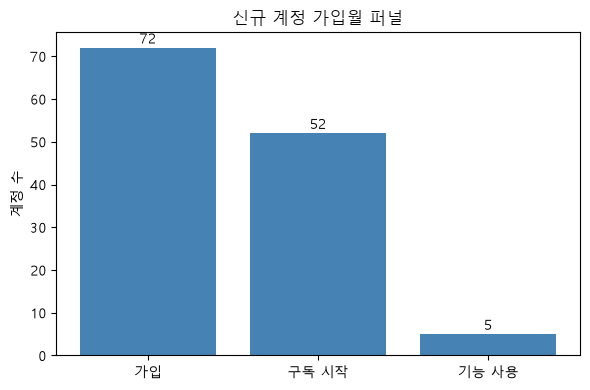

가입 월 기능 사용 도달률: 6.94%


In [4]:
# 필수 1 풀이 코드를 작성하세요.
# 준비 코드의 target, subs, events를 활용하세요.

# 1. 세 단계의 고유 계정 수
signup_accounts = set(target.account_id)

# 구독 시작: 가입 월 안에 시작된 구독
subs_same_month = subs[subs.start_date.dt.to_period("M") == subs.signup_date.dt.to_period("M")]
activation_accounts = set(subs_same_month.account_id)

# 기능 사용: 가입 월 안에 실제 사용 (month_offset == 0)
usage_accounts = set(events.loc[events.month_offset == 0, "account_id"])

n1, n2, n3 = len(signup_accounts), len(activation_accounts), len(usage_accounts)

# 2. 퍼널 표
funnel = pd.DataFrame({"stage": ["가입", "구독 시작", "기능 사용"], "accounts": [n1, n2, n3]})
funnel["step_conversion_pct"] = (funnel["accounts"] / funnel["accounts"].shift(1) * 100).round(2)
funnel["step_drop_pct"] = (100 - funnel["step_conversion_pct"]).round(2)
funnel["not_reached"] = (funnel["accounts"].shift(1) - funnel["accounts"])
display(funnel)

# 3. 시각화
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(funnel["stage"], funnel["accounts"], color="steelblue")
for i, v in enumerate(funnel["accounts"]):
    ax.text(i, v + 1, str(v), ha="center")
ax.set_ylabel("계정 수")
ax.set_title("신규 계정 가입월 퍼널")
plt.tight_layout()
plt.show()

# 4. 가입 월 기능 사용 도달률
reach_rate = n3 / n1 * 100
print(f"가입 월 기능 사용 도달률: {reach_rate:.2f}%")

### 서술 답안

Q1. 가입 72명 → 구독 시작 52명(전환율 72.22%, 이탈률 27.78%, 미도달 20명) → 기능 사용 5명(전환율 9.62%, 이탈률 90.38%, 미도달 47명)이다.

Q2. 가장 낮은 전환율 구간은 구독 시작 → 기능 사용(9.62%)이다. 이는 초기 가설("가입→구독 시작보다 구독 시작→기능 사용 구간의 전환율이 낮을 것")과 방향은 일치하지만, 실제로는 가설보다 훨씬 더 심각한 수준(90% 이상 이탈)으로 나타났다.

Q3. 가입 월 기능 사용 도달률은 **6.94%**다. 마지막 구간 전환율(9.62%)은 분모가 구독을 시작한 52명(이전 단계 통과자)인 반면, 도달률(6.94%)은 분모가 전체 대상 가입 계정 72명이다. 구독 시작 단계에서 이미 빠진 20명까지 포함해서 계산하기 때문에 도달률이 마지막 구간 전환율보다 더 낮게 나온다.

Q4. 한 계정이 여러 구독이나 여러 사용 기록을 남길 수 있으므로, 중복 제거(고유 계정 수) 없이 세면 실제보다 인원이 부풀려진다. 이 결과만으로 미사용 원인을 확정할 수는 없다. 전환율이 낮다는 "현상"은 확인됐지만, 왜 낮은지(온보딩 부족, 기능 발견 어려움 등)는 별도 데이터로 확인해야 한다.

---

## 필수 2 — 가입 월별 기능 사용 리텐션 비교

### 상황

필수 1의 7·8·9월 가입 계정을 같은 가입 월 코호트로 묶습니다. 재방문을 직접 측정하는 로그인 로그가 없으므로 **해당 월의 실제 기능 사용을 재방문의 기준 행동**으로 사용합니다.

### 수행 사항

1. 코호트별 분모는 가입 계정 전체로 고정합니다. M0는 가입 시점의 기준 규모 100%이며 **가입 월 기능 사용률 100%라는 뜻이 아닙니다.** M1~M3는 가입 다음 달부터 3개월째까지, 해당 달에 실제 사용한 계정 수 / 코호트 가입 계정 수 × 100입니다.
2. 월별 사용 계정 수 표와 M0~M3 리텐션 표·선그래프를 만드세요. 사용 월과 가입 월의 차이는 준비 코드의 `month_offset`을 활용합니다.
3. M3 리텐션 최고·최저 코호트를 찾고, M1→M2·M2→M3 변화폭(%p)을 비교하세요.
4. 계속 감소하거나 안정되는지, 아니면 다른 패턴인지 실제 출력에 맞게 해석하세요.

이번 코호트는 모두 M3 월말까지 관찰 가능한지 먼저 확인합니다. 월별 사용자는 이전 달 사용자의 부분집합일 필요가 없으며, 중간에 사용하지 않다가 다시 사용한 계정도 셉니다. 아직 관찰하지 못한 달을 미사용 0명으로 채우면 안 됩니다.

### 질문

Q1. 코호트별 가입 계정 수와 M1~M3 실제 사용 계정 수·리텐션은 얼마인가요?

Q2. M3 리텐션의 최고·최저 코호트와 차이(%p)는 얼마인가요?

Q3. 변화폭으로 볼 때 매월 감소한다는 가설이 맞나요? 정착 시점을 확정할 수 있나요?

Q4. 코호트 차이를 제품 개선 효과로 단정할 수 있나요? 추가로 어떤 기록을 확인해야 하나요?

### 체크 포인트

가입 월 기준 코호트, 고정 분모와 중복 제거, 관찰 기간 확인, 그래프와 일치하는 해석.


2024-07 -> M3 해당월: 2024-10 관찰가능: True
2024-08 -> M3 해당월: 2024-11 관찰가능: True
2024-09 -> M3 해당월: 2024-12 관찰가능: True


month_offset,0,1,2,3
cohort,,,,
2024-07,2,7,11,18
2024-08,1,6,14,15
2024-09,2,14,19,18


,M0,M1,M2,M3
cohort,,,,
2024-07,100.0,26.92,42.31,69.23
2024-08,100.0,28.57,66.67,71.43
2024-09,100.0,56.00,76.00,72.00


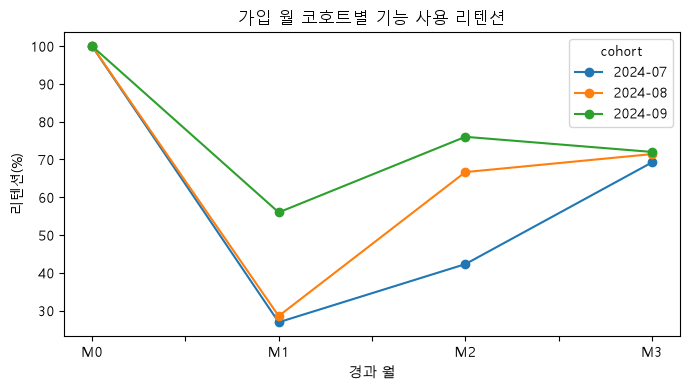

M3 최고: 2024-09 72.0
M3 최저: 2024-07 69.23
M3 차이(%p): 2.77


,M1,M2,M3
cohort,,,
2024-07,NaN,15.38,26.92
2024-08,NaN,38.10,4.76
2024-09,NaN,20.00,-4.00


In [5]:
# 필수 2 풀이 코드를 작성하세요.
# 준비 코드의 target, subs, events를 활용하세요.
cohort_sizes = target.groupby("cohort").size()

# 관찰 가능 여부 확인 (M3까지)
for c in cohort_sizes.index:
    obs_month3 = c + 3
    print(c, "-> M3 해당월:", obs_month3, "관찰가능:", obs_month3 <= analysis_end.to_period("M"))

# 월별(M0~M3) 사용 계정 수
monthly_users = (events[events.month_offset.between(0, 3)]
                  .drop_duplicates(["account_id", "cohort", "month_offset"]))
pivot = monthly_users.groupby(["cohort", "month_offset"])["account_id"].nunique().unstack(fill_value=0)
display(pivot)

# 리텐션 표 (분모는 코호트 가입 계정 수로 고정, M0는 정의상 100%)
retention = pivot.div(cohort_sizes, axis=0) * 100
retention[0] = 100.0
retention = retention[[0, 1, 2, 3]]
retention.columns = ["M0", "M1", "M2", "M3"]
display(retention.round(2))

# 선그래프
retention[["M0", "M1", "M2", "M3"]].T.plot(marker="o", figsize=(7, 4))
plt.ylabel("리텐션(%)")
plt.xlabel("경과 월")
plt.title("가입 월 코호트별 기능 사용 리텐션")
plt.tight_layout()
plt.show()

# M3 최고/최저, 변화폭
m3 = retention["M3"]
print("M3 최고:", m3.idxmax(), round(m3.max(), 2))
print("M3 최저:", m3.idxmin(), round(m3.min(), 2))
print("M3 차이(%p):", round(m3.max() - m3.min(), 2))

diffs = retention[["M1", "M2", "M3"]].diff(axis=1)
display(diffs.round(2))

### 서술 답안

Q1. 코호트별 가입 계정 수는 2024-07=26, 08=21, 09=25명이다. M1 실제 사용 계정 수는 7·6·14명(리텐션 26.92%/28.57%/56.00%), M2는 11·14·19명(42.31%/66.67%/76.00%), M3는 18·15·18명(69.23%/71.43%/72.00%)이다.

Q2. M3 리텐션 최고 코호트는 2024-09(72.00%), 최저는 **2024-07(69.23%)**이며, 차이는 2.77%p로 매우 작다.

Q3. 변화폭을 보면 세 코호트 모두 M1→M2, M2→M3에서 감소가 아니라 증가했다(2024-09만 M2→M3에서 −4.00%p로 소폭 감소). 따라서 "이후 기능 사용률은 매월 감소할 것"이라는 초기 가설과는 반대되는 패턴이다. 정착 시점은 아직 확정할 수 없다. 2024-09 코호트만 M2→M3에서 약하게 꺾이는 조짐을 보였을 뿐, 나머지 두 코호트는 M3까지도 계속 상승 중이라 관찰 기간(M3)까지는 안정화됐다고 말하기 어렵다.

Q4. 코호트 간 M3 리텐션 차이(2.77%p)는 매우 작아서 이를 제품 개선 효과로 단정할 수 없다. 추가로 확인할 기록으로는 해당 시기의 제품 변경·기능 릴리스 이력, 마케팅/유입 경로 변화, 계절적 요인(가입 시점별 산업 특성 등)을 들 수 있다.

---

## 과제 1 — 개선 우선순위와 개선 시나리오

### 상황

필수 분석 결과를 근거로 실행할 개선안 하나를 제안합니다. 목표 지표는 **가입 월 기능 사용 도달률**입니다. 과제는 필수 수준이며 새로운 분석 기법이나 통계 검정을 요구하지 않습니다.

### 수행 사항

1. 아래 후보의 영향 계정 수와 전체 대상 가입 계정 대비 비율을 계산하세요.
   - A: 가입 월에 구독을 시작하지 않은 계정
   - B: 가입 월에 구독을 시작했지만 가입 월 기능 사용까지 도달하지 않은 계정
   - C: M3 리텐션 최저 코호트 중 M3에 사용하지 않은 계정

2. A·B·C를 교안의 네 기준인 **영향 범위, 목표 지표 연관성, 개선 가능성, 검증 용이성**으로 비교하세요. 영향 범위는 계산값을 적고, 나머지는 이유를 서술합니다. 근거 없는 점수나 상·중·하 등급은 요구하지 않습니다. 후보끼리 중복될 수 있으므로 비율을 합산하지 않습니다.

3. 우선순위 1개를 선택하고, 해당 이슈가 어떤 AARRR 단계에 해당하는지 설명하세요. 선정 근거에는 퍼널과 리텐션의 분석 수치를 함께 사용하세요. 이후 이상 신호, 개선안, 기대 효과, A/B 테스트 아이디어를 작성하세요. 개선안에는 “어떤 원인 때문에 문제가 발생하며, 어떤 변경을 하면 목표 지표가 개선될 것이다”라는 검증 가능한 가설을 포함하세요. 기대 효과는 현재 값과 예상 개선폭·목표값을 제시하되 가정임을 밝히세요.

4. A/B 아이디어에는 대상, A의 기존 경험, B의 변경 경험, 양쪽에 동일하게 적용할 비교 지표의 분자·분모·관찰 기간을 적으세요. 실제 실험 수행·유의성 검정은 하지 않습니다.

5. 가설이 지지되지 않았을 때의 대안 또는 실행 방안의 제약 조건을 한 가지 이상 작성하세요. 대안을 선택하면 다음에 무엇을 바꾸거나 확인할지 설명하고, 제약 조건을 선택하면 인력·일정·개발 자원·데이터 확보 등의 조건이 실행에 어떤 영향을 주는지 설명하세요.

### 질문

Q1. 세 후보의 영향 계정 수와 전체 대상 대비 비율은 얼마인가요?

Q2. 네 가지 기준을 적용하면 무엇을 우선하며, 영향 계정 수만으로 결정하면 안 되는 이유는 무엇인가요?

Q3. 선택한 이슈는 어떤 AARRR 단계에 해당하며, 원인 가설과 네 항목의 개선 시나리오는 무엇인가요?

Q4. 제시한 목표값은 관측 결과인가요, 예상인가요? 원인과 효과를 어떻게 구분했나요?

Q5. 가설이 지지되지 않으면 어떤 대안을 검토하겠나요? 또는 실행 시 어떤 제약 조건을 고려해야 하나요? 둘 중 하나를 선택하여 설명하세요.

### 제출물 / 체크 포인트

과제의 계산 코드·출력, 네 기준 비교표, 퍼널·리텐션 수치에 근거한 우선순위와 AARRR 단계, 원인 가설을 포함한 네 항목의 개선 시나리오, 가설이 지지되지 않을 때의 대안 또는 실행 제약 조건, Q1~Q5 답변을 제출합니다. 필수 1·2는 연습용이며, 과제 판단에 사용한 분석 수치는 과제 답안에도 명시하세요. 정답의 우선순위와 달라도 계산과 목표 지표 연결이 타당하고 검증 가능한 시나리오이면 인정합니다.

In [6]:
# 과제 1 풀이 코드를 작성하세요.
# 준비 코드의 target, subs, events를 활용하세요.
all_target = set(target.account_id)
A_accounts = all_target - activation_accounts
B_accounts = activation_accounts - usage_accounts
lowest_m3_cohort = m3.idxmin()   # 2024-07
cohort_accounts = set(target.loc[target.cohort == lowest_m3_cohort, "account_id"])
m3_users = set(events.loc[events.month_offset == 3, "account_id"])
C_accounts = cohort_accounts - m3_users

print(f"A: {len(A_accounts)}명 ({len(A_accounts)/len(all_target)*100:.2f}%)")
print(f"B: {len(B_accounts)}명 ({len(B_accounts)/len(all_target)*100:.2f}%)")
print(f"C: {len(C_accounts)}명 (전체 대비 {len(C_accounts)/len(all_target)*100:.2f}%, "
      f"코호트 내 {len(C_accounts)/len(cohort_accounts)*100:.2f}%)")

A: 20명 (27.78%)
B: 47명 (65.28%)
C: 8명 (전체 대비 11.11%, 코호트 내 30.77%)


Q1.
A는 20명(27.78%), B는 47명(65.28%), C는 8명(전체 대비 11.11%, 코호트 내 비율로는 30.77%)이다.

Q2.
네 기준을 다 같이 보면 B를 우선하게 되는 것 같다. 영향 계정 수만으로 결정하면 안 되는 이유는, 영향 범위가 크다고 해도 그 문제에 실제로 개입할 수 있는 방법이 있는지(개선 가능성), 목표 지표랑 직접 연결되는지, 측정하고 비교하기 쉬운지까지 같이 봐야 하기 때문이다. 예를 들어 A는 영향 범위(27.78%)가 있긴 한데 왜 구독을 안 시작했는지 원인이 다양하고 불분명해서 바로 실행할 개선안을 정하기가 어려웠다.

Q3.
선택한 이슈는 Activation(활성화) 단계에 해당한다고 생각한다. 원인 가설은 "구독을 시작한 직후에 온보딩 안내가 부족해서 기능 사용까지 이어지지 못한다"이고, 개선 시나리오는 다음과 같다.

- 이상 신호: 구독 시작 → 기능 사용 전 단계 대비 전환율이 9.62%(52명 중 5명만 사용)로 너무 낮고, 가입 월 기능 사용 도달률도 6.94%밖에 안 된다.
- 개선안: 구독 시작 직후에 핵심 기능 사용을 유도하는 온보딩 체크리스트나 가이드를 제공하면 이 전환율이 올라갈 것이다.
- 기대 효과: 지금 전환율이 9.62%인데, 온보딩을 개선해서 30% 정도까지 오른다고 가정하면(어디까지나 가정임) 도달률도 현재 6.94%에서 약 20.8%까지는 올라갈 수 있을 것 같다.
- A/B 테스트 아이디어: 대상은 가입 월에 구독을 시작한 신규 계정이고, A(기존)는 별도 안내 없이 그대로 두고, B(변경)는 구독 시작 직후 온보딩 체크리스트를 제공한다. 비교 지표는 가입 월 기능 사용 도달률(가입 월 안에 실제 사용한 계정 수 ÷ 구독 시작한 계정 수)이고, 관찰 기간은 각 계정의 구독 시작일부터 가입 월 말까지로 잡았다.

Q4.
내가 제시한 목표값(전환율 30%, 도달률 20.8%)은 실제로 관측된 결과가 아니라 그냥 예상(가정)이다. 진짜 관측된 숫자는 현재 전환율 9.62%랑 도달률 6.94%뿐이다. 원인은 "온보딩이 부족해서"라고 가설로 세운 거고, 그 가설이 맞는다면 나타날 효과(전환율이나 도달률이 얼마나 오를지)는 실제로 실험을 해봐야 알 수 있는 부분이라서 원인이랑 효과를 구분해서 썼다.

Q5.
가설이 지지되지 않았을 때의 대안 쪽으로 생각해봤다. 온보딩 체크리스트를 줬는데도 전환율이 그대로라면, 문제가 안내가 부족해서가 아니라 기능 자체를 발견하기 어렵거나 애초에 필요성을 못 느끼는 거일 수도 있을 것 같다. 그러면 다음엔 어떤 기능을 먼저 보여줄지 순서를 다시 검토하거나, 사용자들한테 직접 물어봐서 실제로 어떤 부분이 걸림돌인지 확인하는 쪽으로 넘어가야 할 것 같다.

---

## 실습 마무리

- 어떤 분석 문제가 있었는가?
- 어떤 분석적 방법을 적용했는가?
- 무엇을 근거로 결론을 내렸는가?